# Find and save the NRMSE for each canton

In [8]:
import pandas as pd
import sys
import numpy as np
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
from mapie.regression import TimeSeriesRegressor
from mapie.subsample import BlockBootstrap
import joblib
from arch.bootstrap import CircularBlockBootstrap
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.base import clone

sys.path.append('../../models')

from model_rr import Model, Hybrid

In [2]:
cantons = [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 201, -202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 301, 302, 303, 304, 305, 306, 307, 308, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 701, 702, 703, 704, 705, 706]

cantons = [str(x) for x in cantons]

In [3]:
df = pd.read_csv('../../data/clean/full_data.csv')

# Function

In [ ]:
def calculate_rmse_for_each(model_type, cantons, epsilon = 0.2):
    results = pd.read_csv(f'../../data/model_results/results_{model_type}_full.csv')
    nrmse = []
    cod_canton = []
    for canton in cantons:
        results_canton = results[results["week_canton"].str.contains(canton)]
        rmse_temp = root_mean_squared_error(results_canton["actual"], results_canton["pred"])
        nrmse_temp = rmse_temp / (np.mean(results_canton["actual"]) + epsilon)
        cod_canton.append(canton)
        nrmse.append(nrmse_temp)
    df_nrmse = pd.DataFrame({"canton": cod_canton, "nrmse": nrmse})
    df_nrmse.to_csv(f"../../data/model_results/metrics/{model_type}_full.csv", index = False)

def prediction_intervals(X_combined, y_combined, X_test, epsilon, model_type, repeats):

        try:
            grid_reg = joblib.load(f'../../models/saved_models/{model_type}_reg_full.joblib')
        except FileNotFoundError: 
            grid_reg = joblib.load(f'../../models/saved_models/{model_type}_full.joblib')

        best_model = grid_reg.best_estimator_

        cv_mapiets = BlockBootstrap(
            n_resamplings=repeats, length = 12, overlapping=True, random_state=42
        )

        if model_type == "hrf" or model_type == "hxgb":
            try:
                grid_classi = joblib.load(f'../../models/saved_models/{model_type}_classi_full.joblib')
            except FileNotFoundError
                grid_classi = None

            thresholds = pd.read_csv(f"../../data/model_results/thresholds/full_threshold_{model_type}.csv")
            thresholds["canton"] = thresholds["canton"].astype(str)
            best_threshold = thresholds.iloc[0, 1]
            classifier = None if grid_classi is None else grid_classi.best_estimator_
            best_model = Hybrid(
                    classifier= classifier,
                    regressor= grid_reg.best_estimator_,
                    threshold= best_threshold,
                    epsilon = epsilon
            )

        mapie_reg = TimeSeriesRegressor(
            best_model, method="enbpi", cv=cv_mapiets, agg_function="mean", n_jobs=-1, random_state = 42
        )

        mapie_reg.fit(X_combined, y_combined)

        y_pred_cp, y_interval = mapie_reg.predict(X_test, ensemble = True, confidence_level = 0.95)

        lower_bound = np.exp(y_interval[:, 0, 0]) - epsilon
        upper_bound = np.exp(y_interval[:, 1, 0]) - epsilon

        y_pred_point = np.exp(y_pred_cp) - epsilon

        return y_pred_point, lower_bound, upper_bound

def ticks_years_top(ax, n):

        [l.set_visible(False) for (i,l) in enumerate(ax.xaxis.get_ticklabels()) if i % n != 0]
        for i, tick in enumerate(ax.xaxis.get_major_ticks()):
            if i % n != 0:
                tick.tick1line.set_visible(False)
                tick.tick2line.set_visible(False)
                tick.gridline.set_visible(False) 

def serie_temp_canton(canton, model_type, y_pred_point, lower_bound, upper_bound):
      
        results_full = pd.read_csv(f'../../data/model_results/results_{model_type}_full.csv')

        results = results_full[results_full["week_canton"].str.contains(canton)]
        
        results['week_canton'] = results['week_canton'].str.extract(r'(\d{4}-\d+)').iloc[:, 0].tolist()

        fig, ax = plt.subplots()
        ax.plot(results['week_canton'], results["actual"], label='Real', marker='o', linestyle = "dashed", color = "blue")
        ax.plot(results['week_canton'], results["pred"], label='Predicted', marker='o', color = "red")
        ax.plot(results['week_canton'], y_pred_point, label='Conformal predictions', marker='o', color = "green")
        ax.fill_between(x = results['week_canton'], label = "CI (95%)", y1 = lower_bound, y2 = upper_bound, alpha = 0.2, color = "green")
        ax.legend(loc = "upper right")
        ticks_years_top(ax, 20)
        ax.set_xlabel('Week')
        ax.set_ylabel(f'Relative risk')

        ax.set_title(f"{model_type} for {canton}")
        plt.show()

def confint_nrmse(model_type, X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100):

        # Check if there's a classifier model if it's a hybrid model type
        try:
            grid_classi = joblib.load(f'../../models/saved_models/{model_type}_classi_full.joblib')
        except FileNotFoundError: 
            grid_classi = None

        # The file names are different for the regression models (with "_reg" in the name) and the hybrid models (without "_reg" in the name), so we need to try both options when loading the model.
        try:
            grid_reg = joblib.load(f'../../models/saved_models/{model_type}_reg_full.joblib')
        except FileNotFoundError: 
            grid_reg = joblib.load(f'../../models/saved_models/{model_type}_full.joblib')
        
        best_params_reg = grid_reg.best_params_

        y_test = np.exp(y_test) - epsilon

        X_arr = X_combined
        y_arr = y_combined

        bs = CircularBlockBootstrap(
            12,
            X_arr,
            y_arr,
            seed = 42
        )

        models = []
        prediction_probs_classi = []

        if grid_classi == None and model_type == "hrf":
                print("Only one class present in test set for classification. Skipping classification step.")
        elif grid_classi == None and model_type == "hxgb":
                print("Only one class present in test set for classification. Skipping classification step.")

        for data in bs.bootstrap(n_bootstraps):

            X_boot = data[0][0]
            y_boot = data[0][1]

            if model_type == "rf":
                modelo = RandomForestRegressor(**best_params_reg, random_state = 42)
                modelo.fit(X_boot, y_boot)
                models.append(modelo)
            elif model_type == "xgb":
                modelo = XGBRegressor(**best_params_reg, random_state = 42) 
                modelo.fit(X_boot, y_boot)
                models.append(modelo)
            elif model_type == "hrf":
                thresholds = pd.read_csv("../../data/model_results/thresholds/full_threshold_hrf.csv")
                thresholds["canton"] = thresholds["canton"].astype(str)
                best_threshold = thresholds.iloc[0, 1]

                y_boot_actual = np.exp(y_boot) - epsilon
                y_boot_binary = pd.Series((y_boot_actual > 0).astype(int))

                if len(np.unique(y_boot_binary)) < 2:
                    continue

                # Skip classification step if classifier was not used in the original model
                if grid_classi != None:
                    modelo_classi = grid_classi.best_estimator_
                    modelo_classi.fit(X_boot, y_boot_binary)
                    prob_classi = modelo_classi.predict_proba(X_test)[:, 1]
                    prediction_probs_classi.append(prob_classi)

                mask_pos_train = y_boot_actual > 0 
                X_boot_1 = X_boot[mask_pos_train]
                y_boot_1 = y_boot[mask_pos_train]
                if mask_pos_train.sum() == 0:
                    continue
                else:   
                    modelo_reg = RandomForestRegressor(**best_params_reg, random_state = 42)
                    modelo_reg.fit(X_boot_1, y_boot_1)
                    models.append(modelo_reg)
            elif model_type == "hxgb":
                thresholds = pd.read_csv("../../data/model_results/thresholds/full_threshold_hxgb.csv")
                thresholds["canton"] = thresholds["canton"].astype(str)
                best_threshold = thresholds.iloc[0, 1]

                y_boot_actual = np.exp(y_boot) - epsilon
                y_boot_binary = pd.Series((y_boot_actual > 0).astype(int))

                if len(np.unique(y_boot_binary)) < 2:
                    continue

                # Skip classification step if classifier was not used in the original model
                if grid_classi != None:
                    modelo_classi = grid_classi.best_estimator_
                    modelo_classi.fit(X_boot, y_boot_binary)
                    prob_classi = modelo_classi.predict_proba(X_test)[:, 1]
                    prediction_probs_classi.append(prob_classi)

                mask_pos_train = y_boot_actual > 0 
                X_boot_1 = X_boot[mask_pos_train]
                y_boot_1 = y_boot[mask_pos_train]
                if mask_pos_train.sum() == 0:
                    continue
                else:   
                    modelo_reg = XGBRegressor(**best_params_reg, random_state = 42)
                    modelo_reg.fit(X_boot_1, y_boot_1)
                    models.append(modelo_reg)
        # If there's no classification model in the hybrid case, predictions can be obtained directly from the regression model. However, in the other case, predicted cases by the regression model are changed if the classifier model first predicted that they were zero
        if grid_classi == None:                     
            predictions = np.array([model.predict(X_test) for model in models])
            predictions = np.exp(predictions) - epsilon
        else: 
            predictions_reg = np.array([model.predict(X_test) for model in models])
            predictions_reg = np.exp(predictions_reg) - epsilon
            predictions = np.array([np.where(prob < best_threshold, 0, y_pred_reg) for prob, y_pred_reg in zip(prediction_probs_classi, predictions_reg)])


        nrmse = np.array([root_mean_squared_error(y_true = y_test, y_pred = pred) / (np.mean(y_test) + epsilon) for pred in predictions])

        y_pred_point = np.mean(nrmse)

        lower_bound = np.percentile(nrmse, 2.5)
        upper_bound = np.percentile(nrmse, 97.5)

        print(f"point estimate: {round(y_pred_point, 2)}")
        print(f"lower bound: {round(lower_bound, 2)}, upper bound: {round(upper_bound, 2)}")

# RF

In [41]:
calculate_rmse_for_each("rf", cantons)

In [42]:
df_nrmse_rf = pd.read_csv(f"../../data/model_results/metrics/rf_full.csv")

## Best RF

In [43]:
df_nrmse_rf = pd.read_csv(f"../../data/model_results/metrics/rf_full.csv")
best_rf_canton = df_nrmse_rf.iloc[df_nrmse_rf["nrmse"].idxmin(), 0]
results_rf = pd.read_csv(f'../../data/model_results/results_rf_full.csv')

In [44]:
best_rf = Model(df, str(best_rf_canton))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = best_rf.partition()

### Plot

In [45]:
y_pred_point, lower_bound, upper_bound = prediction_intervals(X_combined, y_combined, X_test, epsilon, "rf", repeats = 100)

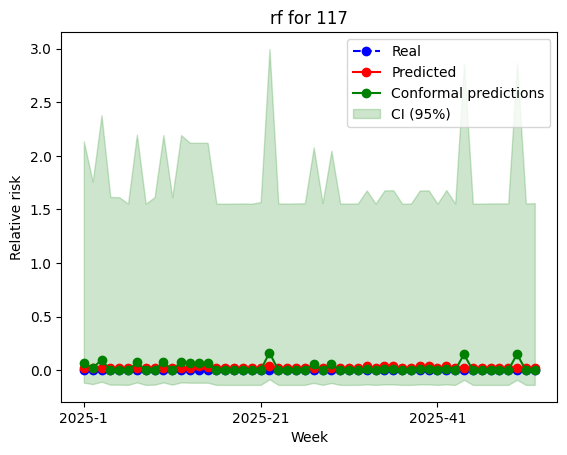

In [46]:
serie_temp_canton(str(best_rf_canton), "rf", y_pred_point, lower_bound, upper_bound)

### NRMSE

In [47]:
np.min(df_nrmse_rf["nrmse"])

np.float64(0.1323507975992561)

In [55]:
confint_nrmse("rf", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100)

point estimate: 3.67
lower bound: 3.6, upper bound: 3.96


## Worst RF

In [49]:
df_nrmse_rf = pd.read_csv(f"../../data/model_results/metrics/rf_full.csv")
worst_rf_canton = df_nrmse_rf.iloc[df_nrmse_rf["nrmse"].idxmax(), 0]
results_rf = pd.read_csv(f'../../data/model_results/results_rf_full.csv')

In [50]:
worst_rf = Model(df, str(worst_rf_canton))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = worst_rf.partition()

### Plot

In [51]:
y_pred_point, lower_bound, upper_bound = prediction_intervals(X_combined, y_combined, X_test, epsilon, "rf", repeats = 100)

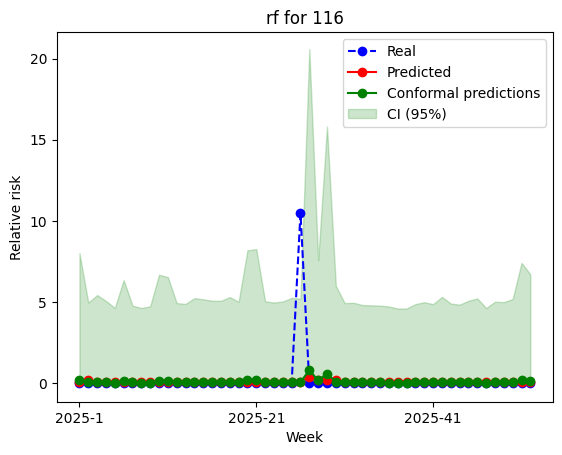

In [52]:
serie_temp_canton(str(worst_rf_canton), "rf", y_pred_point, lower_bound, upper_bound)

### NRMSE

In [53]:
np.max(df_nrmse_rf["nrmse"])

np.float64(3.606963778222847)

In [54]:
confint_nrmse("rf", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100)

point estimate: 3.67
lower bound: 3.6, upper bound: 3.96


# XGB

In [56]:
calculate_rmse_for_each("xgb", cantons)

## Best XGB

In [106]:
df_nrmse_xgb = pd.read_csv(f"../../data/model_results/metrics/xgb_full.csv")
best_xgb_canton = df_nrmse_xgb.iloc[df_nrmse_xgb["nrmse"].idxmin(), 0]
results_xgb = pd.read_csv(f'../../data/model_results/results_xgb_full.csv')

In [107]:
best_xgb = Model(df, str(best_xgb_canton))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = best_xgb.partition()

### Plot

In [108]:
y_pred_point, lower_bound, upper_bound = prediction_intervals(X_combined, y_combined, X_test, epsilon, "xgb", repeats = 100)

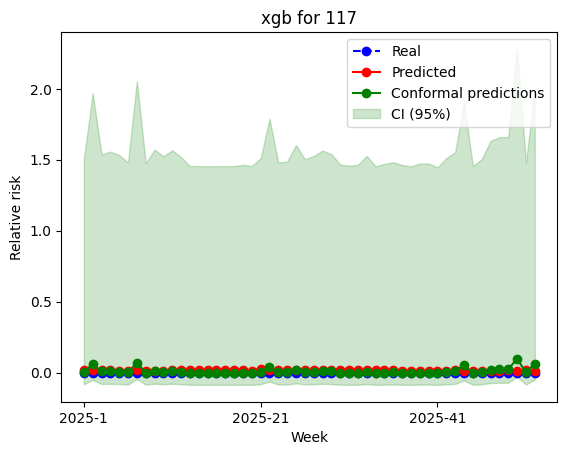

In [109]:
serie_temp_canton(str(best_xgb_canton), "xgb", y_pred_point, lower_bound, upper_bound)

### NRMSE

In [110]:
np.min(df_nrmse_xgb["nrmse"])

np.float64(0.0851632445022881)

In [111]:
confint_nrmse("xgb", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100)

point estimate: 0.41
lower bound: 0.0, upper bound: 1.98


## Worst XGB

In [64]:
df_nrmse_xgb = pd.read_csv(f"../../data/model_results/metrics/xgb_full.csv")
worst_xgb_canton = df_nrmse_xgb.iloc[df_nrmse_xgb["nrmse"].idxmax(), 0]
results_xgb = pd.read_csv(f'../../data/model_results/results_xgb_full.csv')

In [65]:
worst_xgb = Model(df, str(worst_xgb_canton))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = worst_xgb.partition()

### Plot

In [66]:
y_pred_point, lower_bound, upper_bound = prediction_intervals(X_combined, y_combined, X_test, epsilon, "xgb", repeats = 100)

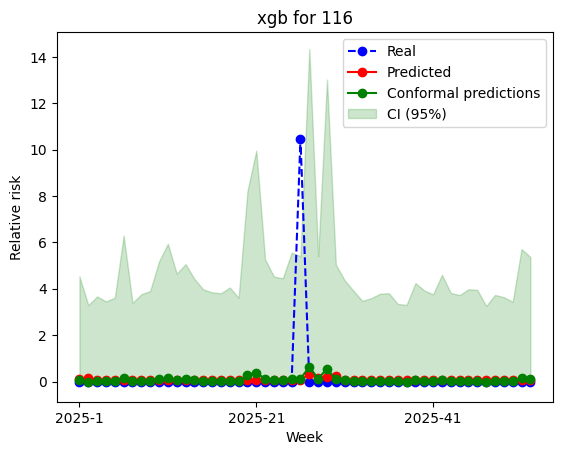

In [67]:
serie_temp_canton(str(worst_xgb_canton), "xgb", y_pred_point, lower_bound, upper_bound)

### NRMSE

In [68]:
np.max(df_nrmse_xgb["nrmse"])

np.float64(3.6041927410491392)

In [69]:
confint_nrmse("xgb", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100)

point estimate: 3.68
lower bound: 3.52, upper bound: 3.89


# HRF

In [70]:
calculate_rmse_for_each("hrf", cantons)

## Best HRF

In [71]:
df_nrmse_hrf = pd.read_csv(f"../../data/model_results/metrics/hrf_full.csv")
best_hrf_canton = df_nrmse_hrf.iloc[df_nrmse_hrf["nrmse"].idxmin(), 0]
results_hrf = pd.read_csv(f'../../data/model_results/results_hrf_full.csv')

In [72]:
best_hrf = Model(df, str(best_hrf_canton))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = best_hrf.partition()

### Plot

In [75]:
y_pred_point, lower_bound, upper_bound = prediction_intervals(X_combined, y_combined, X_test, epsilon, "hrf", repeats = 100)

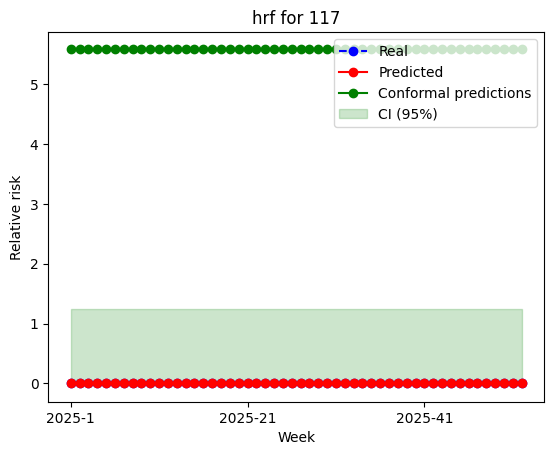

In [76]:
serie_temp_canton(str(best_hrf_canton), "hrf", y_pred_point, lower_bound, upper_bound)

### NRMSE

In [82]:
np.min(df_nrmse_hrf["nrmse"])

np.float64(0.0)

In [83]:
confint_nrmse("hrf", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100)

point estimate: 0.0
lower bound: 0.0, upper bound: 0.0


## Worst HRF

In [84]:
df_nrmse_hrf = pd.read_csv(f"../../data/model_results/metrics/hrf_full.csv")
worst_hrf_canton = df_nrmse_hrf.iloc[df_nrmse_hrf["nrmse"].idxmax(), 0]
results_hrf = pd.read_csv(f'../../data/model_results/results_hrf_full.csv')

In [85]:
worst_hrf = Model(df, str(worst_hrf_canton))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = worst_hrf.partition()

### Plot

In [86]:
y_pred_point, lower_bound, upper_bound = prediction_intervals(X_combined, y_combined, X_test, epsilon, "hrf", repeats = 100)

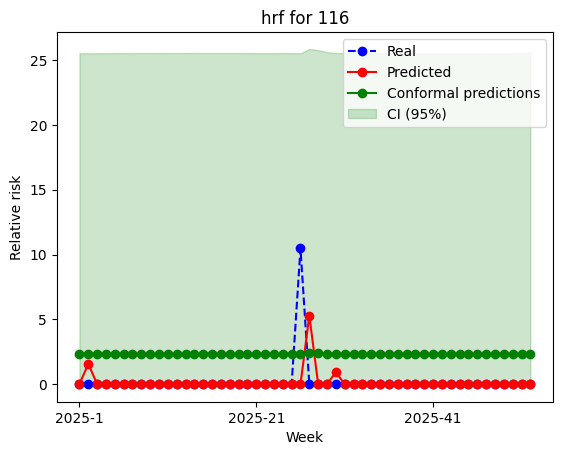

In [87]:
serie_temp_canton(str(worst_hrf_canton), "hrf", y_pred_point, lower_bound, upper_bound)

### NRMSE

In [88]:
np.max(df_nrmse_hrf["nrmse"])

np.float64(4.102655803057578)

In [89]:
confint_nrmse("hrf", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100)

point estimate: 3.71
lower bound: 3.62, upper bound: 4.36


# HXGB

In [90]:
calculate_rmse_for_each("hxgb", cantons)

## Best HXGB

In [91]:
df_nrmse_hxgb = pd.read_csv(f"../../data/model_results/metrics/hxgb_full.csv")
best_hxgb_canton = df_nrmse_hxgb.iloc[df_nrmse_hxgb["nrmse"].idxmin(), 0]
results_hxgb = pd.read_csv(f'../../data/model_results/results_hxgb_full.csv')

In [92]:
best_hxgb = Model(df, str(best_hxgb_canton))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = best_hxgb.partition()

### Plot

In [93]:
y_pred_point, lower_bound, upper_bound = prediction_intervals(X_combined, y_combined, X_test, epsilon, "hxgb", repeats = 100)

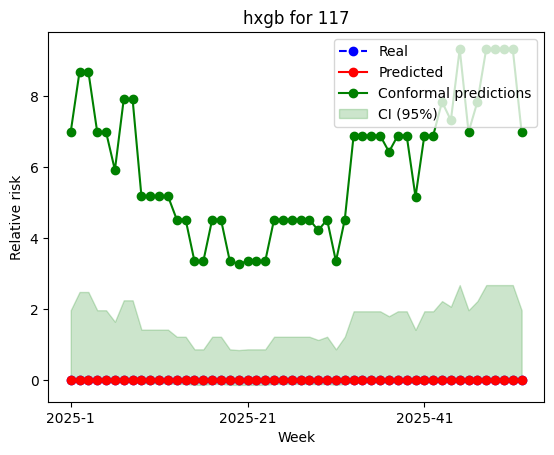

In [94]:
serie_temp_canton(str(best_hxgb_canton), "hxgb", y_pred_point, lower_bound, upper_bound)

### NRMSE

In [95]:
np.min(df_nrmse_hxgb["nrmse"])

np.float64(0.0)

In [104]:
confint_nrmse("hxgb", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100)

point estimate: 3.62
lower bound: 3.62, upper bound: 3.62


## Worst HXGB

In [97]:
df_nrmse_hxgb = pd.read_csv(f"../../data/model_results/metrics/hxgb_full.csv")
worst_hxgb_canton = df_nrmse_hxgb.iloc[df_nrmse_hxgb["nrmse"].idxmax(), 0]
results_hxgb = pd.read_csv(f'../../data/model_results/results_hxgb_full.csv')

In [98]:
worst_hxgb = Model(df, str(worst_hxgb_canton))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = worst_hxgb.partition()

### Plot

In [99]:
y_pred_point, lower_bound, upper_bound = prediction_intervals(X_combined, y_combined, X_test, epsilon, "hxgb", repeats = 100)

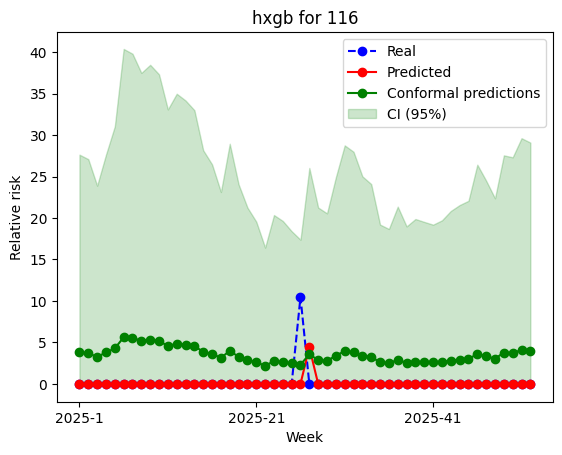

In [100]:
serie_temp_canton(str(worst_hxgb_canton), "hxgb", y_pred_point, lower_bound, upper_bound)

### NRMSE

In [101]:
np.max(df_nrmse_hxgb["nrmse"])

np.float64(3.927050590254052)

In [105]:
confint_nrmse("hxgb", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 100)

point estimate: 3.62
lower bound: 3.62, upper bound: 3.62
